Лабораторна робота №3

Виконав: Верещака Олександр ПР-2-2
Варіант №1

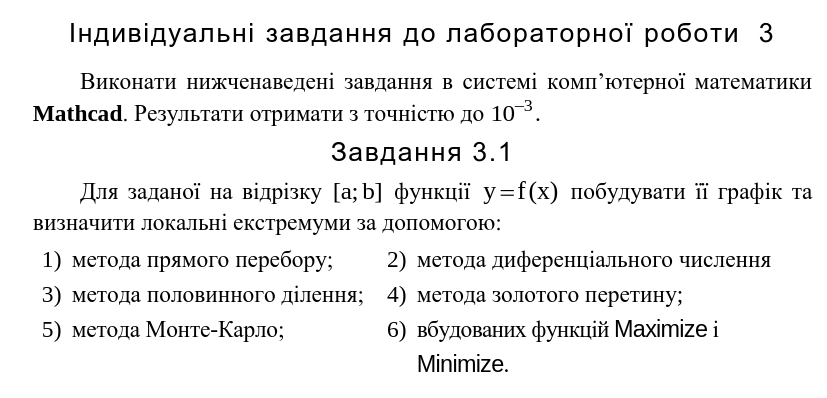

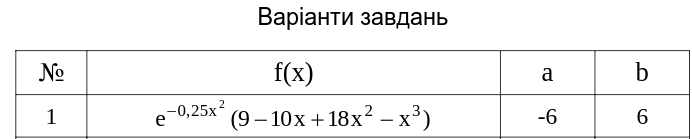

### Хід роботи


=== 1. Метод прямого перебору(Графік) ===

=== 2. Метод диференціального числення ===
Критичні точки:
	->| -1.832330
	->| 0.320162
	->| 1.940148

=== 3. Метод половинного ділення (mpd) ===
Екстремуми через mpd:
	->| -1.8330078125
	->| 0.3193359375
	->| 1.9404296875

=== 4. Метод золотого перетину ===
Метод золотого перетину:
Перший максимум: x = -1.8324
Мінімум:       x = 0.3202
Другий максимум: x = 1.9400

=== 5. Метод Монте-Карло ===
Перший максимум: x = -1.83233
Мінімум:       x = = 0.32016
Другий максимум: x = 1.94014

=== 6. Вбудовані функції (scipy.optimize) ===
Перший максимум: x = -1.83233
Мінімум:       x = = 0.32016
Другий максимум: x = 1.94015


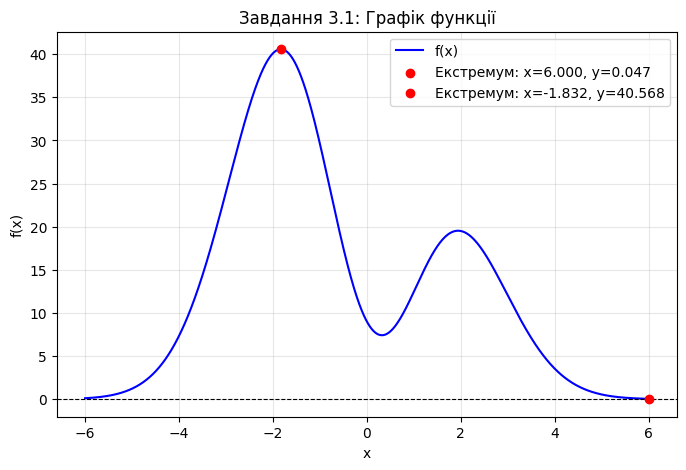

In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.optimize import minimize

x = np.linspace(-6, 6, 10000)


def f(x):
    return np.exp(-0.25 * x**2) * (9 - 10 * x + 18 * x**2 - x**3)


y = f(x)

# ==========================================
# 1. Метод прямого перебору
# ==========================================
print("\n=== 1. Метод прямого перебору(Графік) ===")
index_min = np.argmin(y)
index_max = np.argmax(y)

min_x = x[index_min]
min_y = y[index_min]
max_x = x[index_max]
max_y = y[index_max]

# Будуємо графік функції
plt.figure(figsize=(8, 5))
plt.plot(x, f(x), label="f(x)", color="blue")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.scatter(
    min_x,
    [min_y],
    color="red",
    zorder=5,
    label=f"Екстремум: x={min_x:.3f}, y={min_y:.3f}",
)
plt.scatter(
    max_x,
    [max_y],
    color="red",
    zorder=5,
    label=f"Екстремум: x={max_x:.3f}, y={max_y:.3f}",
)

# ==========================================
# 2. Метод диференціального числення
# ==========================================
print("\n=== 2. Метод диференціального числення ===")
x_sym = sp.Symbol("x")
f_sym = sp.exp(-0.25 * x_sym**2) * (9 - 10 * x_sym + 18 * x_sym**2 - x_sym**3)
f_prime = sp.diff(f_sym, x_sym)

critical_points_raw = sp.solve(sp.Eq(f_prime, 0), x_sym)

critical_points = []
for point in critical_points_raw:
    z = complex(point.evalf())
    if abs(z.imag) < 1e-12 and -6 <= z.real <= 6:
        critical_points.append(z.real)

critical_points.sort()
print("Критичні точки:", *[f"{p:.6f}" for p in critical_points], sep="\n\t->| ")

# ==========================================
# 3. Метод половинного ділення (mpd)
# ==========================================
print("\n=== 3. Метод половинного ділення (mpd) ===")


def mpd(f, a, b, eps=0.001):
    while (b - a) / 2 > eps:
        c = (a + b) / 2
        if f(c) == 0:
            return c
        elif f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return (a + b) / 2


df = sp.lambdify(x_sym, f_prime, "numpy")
# Задаємо відрізки [a, b] для кожного з трьох екстремумів, спираючись на графік
intervals = [(-3, -1), (-1, 1), (1, 3)]

list_res_mpd = [mpd(df, a, b) for a, b in intervals]
print("Екстремуми через mpd:", *list_res_mpd, sep="\n\t->| ")


# ==========================================
# 4. Метод золотого перетину
# ==========================================
print("\n=== 4. Метод золотого перетину ===")


def golden_section_min(f, a, b, eps=1e-3):
    phi = (np.sqrt(5) - 1) / 2
    x1 = b - phi * (b - a)
    x2 = a + phi * (b - a)

    while abs(b - a) > eps:
        if f(x1) < f(x2):
            b = x2
            x2 = x1
            x1 = b - phi * (b - a)
        else:
            a = x1
            x1 = x2
            x2 = a + phi * (b - a)

    return (a + b) / 2


# 1. Шукаємо перший максимум
max1_x = golden_section_min(lambda x: -f(x), intervals[0][0], intervals[0][1])

# 2. Шукаємо мінімум
min_x = golden_section_min(f, intervals[1][0], intervals[1][1])

# 3. Шукаємо другий максимум
min2_x = golden_section_min(lambda x: -f(x), intervals[2][0], intervals[2][1])

print("Метод золотого перетину:")
print(f"Перший максимум: x = {max1_x:.4f}")
print(f"Мінімум:       x = {min_x:.4f}")
print(f"Другий максимум: x = {min2_x:.4f}")

# ==========================================
# 5. Метод Монте-Карло
# ==========================================
print("\n=== 5. Метод Монте-Карло ===")
N = 100000  # Кількість випадкових точок (чим більше, тим точніше результат)

# Генерируем случайные числа на каждом интервале
x_mc1 = np.random.uniform(intervals[0][0], intervals[0][1], N)
x_mc2 = np.random.uniform(intervals[1][0], intervals[1][1], N)
x_mc3 = np.random.uniform(intervals[2][0], intervals[2][1], N)

# Знаходим екстремуми, вибираючи точки з максимальним та мінімальним значенням функції
min1_mc_x = x_mc1[np.argmax(f(x_mc1))]
max_mc_x = x_mc2[np.argmin(f(x_mc2))]
min2_mc_x = x_mc3[np.argmax(f(x_mc3))]

print(f"Перший максимум: x = {min1_mc_x:.5f}")
print(f"Мінімум:       x = = {max_mc_x:.5f}")
print(f"Другий максимум: x = {min2_mc_x:.5f}")


# ==========================================
# 6. Вбудовані функції (scipy.optimize)
# ==========================================
print("\n=== 6. Вбудовані функції (scipy.optimize) ===")

# В якості початкового наближення для кожного екстремуму вибираємо точки, які ми отримали раніше
max1_opt = minimize(lambda x: -f(x), x0=-2.0).x[0]

# Для пошуку мінімуму використовуємо точку, яка була знайдена методом золотого перетину
min_opt = minimize(f, x0=0.0).x[0]

max2_opt = minimize(lambda x: -f(x), x0=2.0).x[0]

print(f"Перший максимум: x = {max1_opt:.5f}")
print(f"Мінімум:       x = = {min_opt:.5f}")
print(f"Другий максимум: x = {max2_opt:.5f}")

plt.title("Завдання 3.1: Графік функції")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()